In [2]:
import pandas as pd
import json

df = pd.read_csv("Luas Daerah dan Jumlah Pulau Menurut Provinsi, 2025.csv")

mapping_pulau = {

    # Sumatera
    "Aceh": "Sumatera",
    "Sumatera Utara": "Sumatera",
    "Sumatera Barat": "Sumatera",
    "Riau": "Sumatera",
    "Jambi": "Sumatera",
    "Sumatera Selatan": "Sumatera",
    "Bengkulu": "Sumatera",
    "Lampung": "Sumatera",
    "Kepulauan Bangka Belitung": "Sumatera",
    "Kepulauan Riau": "Sumatera",

    # Jawa
    "DKI Jakarta": "Jawa",
    "Jawa Barat": "Jawa",
    "Jawa Tengah": "Jawa",
    "DI Yogyakarta": "Jawa",
    "Jawa Timur": "Jawa",
    "Banten": "Jawa",

    # Kalimantan
    "Kalimantan Barat": "Kalimantan",
    "Kalimantan Tengah": "Kalimantan",
    "Kalimantan Selatan": "Kalimantan",
    "Kalimantan Timur": "Kalimantan",
    "Kalimantan Utara": "Kalimantan",

    # Sulawesi
    "Sulawesi Utara": "Sulawesi",
    "Sulawesi Tengah": "Sulawesi",
    "Sulawesi Selatan": "Sulawesi",
    "Sulawesi Tenggara": "Sulawesi",
    "Gorontalo": "Sulawesi",
    "Sulawesi Barat": "Sulawesi",

    # Bali
    "Bali": "Bali",

    # Nusa Tenggara
    "Nusa Tenggara Barat": "Nusa Tenggara",
    "Nusa Tenggara Timur": "Nusa Tenggara",

    # Papua
    "Papua": "Papua",
    "Papua Barat": "Papua",
    "Papua Selatan": "Papua",
    "Papua Tengah": "Papua",
    "Papua Pegunungan": "Papua",
    "Papua Barat Daya": "Papua",

    # Maluku
    "Maluku": "Maluku",
    "Maluku Utara": "Maluku"
}

df["Pulau"] = df["Provinsi"].map(mapping_pulau)

df = df[["Pulau", "Luas Wilayah (Km2)"]]


hasil = df.groupby("Pulau", as_index=False).sum()


total_luas = hasil["Luas Wilayah (Km2)"].sum()

hasil["Persentase Luas Wilayah"] = (
    hasil["Luas Wilayah (Km2)"] / total_luas * 100
)


hasil["Persentase Luas Wilayah"] = (
    hasil["Persentase Luas Wilayah"].round(2)
)


print(hasil)


hasil.to_csv("luas_wilayah_per_pulau.csv", index=False)


hasil.to_json(
    "luas_wilayah_per_pulau.json",
    orient="records",
    indent=4
)

print("File CSV dan JSON berhasil disimpan!")

           Pulau  Luas Wilayah (Km2)  Persentase Luas Wilayah
0           Bali             5582.83                     0.30
1           Jawa           132644.29                     7.17
2     Kalimantan           534426.50                    28.87
3         Maluku            77599.81                     4.19
4  Nusa Tenggara            66010.10                     3.57
5          Papua           373139.13                    20.16
6       Sulawesi           186064.34                    10.05
7       Sumatera           475609.77                    25.69
File CSV dan JSON berhasil disimpan!


## EXPLORATORY DATA ANALYSIS

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv('luas_wilayah_per_pulau.csv')
display(data)

,Pulau,Luas Wilayah (Km2),Persentase Luas Wilayah
0,Bali,5582.83,0.30
1,Jawa,132644.29,7.17
2,Kalimantan,534426.50,28.87
3,Maluku,77599.81,4.19
4,Nusa Tenggara,66010.10,3.57
5,Papua,373139.13,20.16
6,Sulawesi,186064.34,10.05
7,Sumatera,475609.77,25.69


In [6]:
display(data.describe())

,Luas Wilayah (Km2),Persentase Luas Wilayah
count,8.000000,8.000000
mean,231384.596250,12.500000
std,201906.334224,10.906623
min,5582.830000,0.300000
25%,74702.382500,4.035000
50%,159354.315000,8.610000
75%,398756.790000,21.542500
max,534426.500000,28.870000


,Pulau,Luas Wilayah (Km2),Persentase Luas Wilayah
2,Kalimantan,534426.50,28.87
7,Sumatera,475609.77,25.69
5,Papua,373139.13,20.16
6,Sulawesi,186064.34,10.05
1,Jawa,132644.29,7.17
3,Maluku,77599.81,4.19
4,Nusa Tenggara,66010.10,3.57
0,Bali,5582.83,0.30


C:\Users\Adrian Alfarisi\AppData\Local\Temp\ipykernel_15688\524797057.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Luas Wilayah (Km2)', y='Pulau', data=data_sorted, palette='viridis', ax=ax)


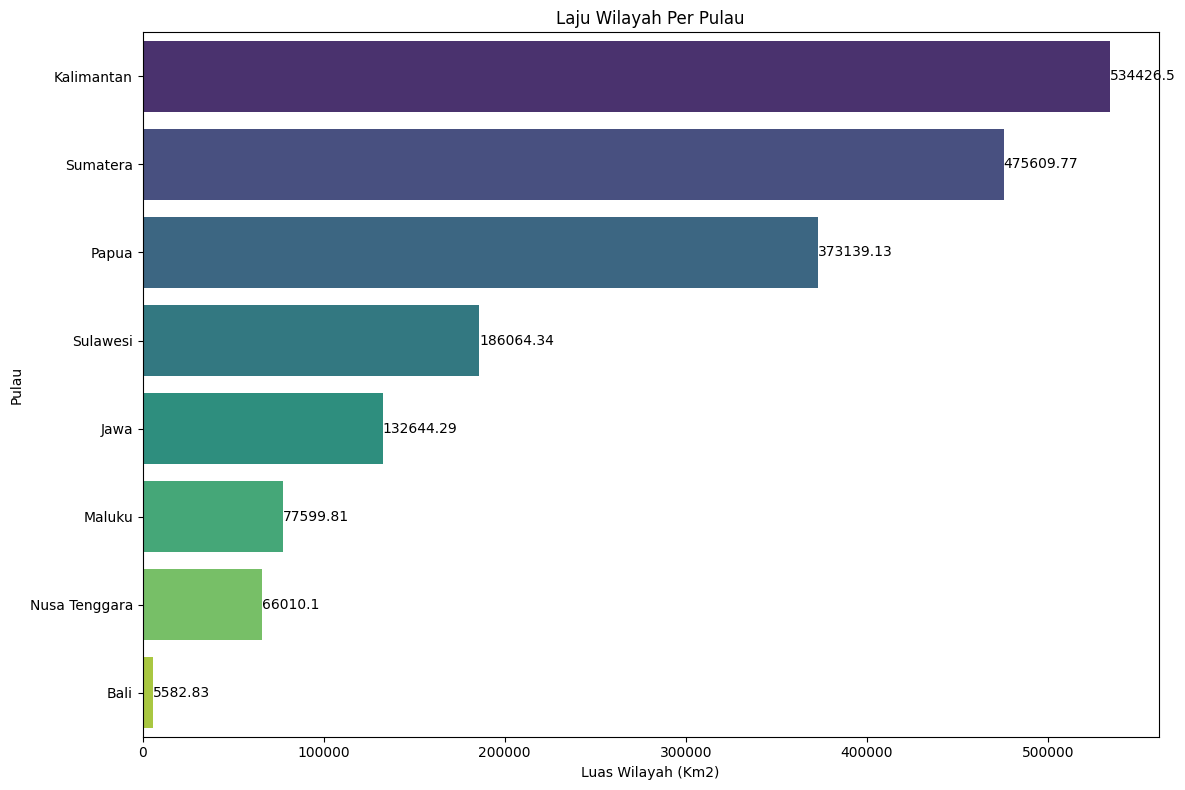

In [15]:
data_sorted = data.sort_values(by='Luas Wilayah (Km2)', ascending=False)
display(data_sorted)

fig, ax = plt.subplots(figsize=(12,8))
sns.barplot(x='Luas Wilayah (Km2)', y='Pulau', data=data_sorted, palette='viridis', ax=ax)

for index, value in enumerate(data_sorted['Luas Wilayah (Km2)']):
    ax.text(value, index, f'{value}', va='center')

ax.set_title('Laju Wilayah Per Pulau')
ax.set_ylabel('Pulau')
plt.tight_layout()
plt.show()

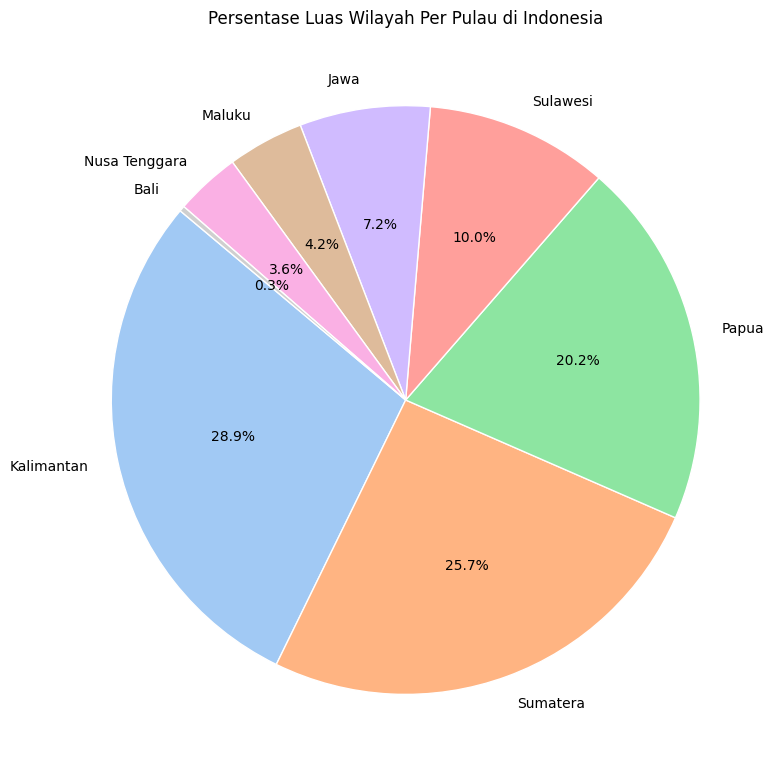

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette('pastel')[0:8]

data_luas = data.sort_values(by='Persentase Luas Wilayah', ascending=False)

ax.pie(data_luas['Persentase Luas Wilayah'], 
       labels=data_luas['Pulau'], 
       autopct='%1.1f%%', 
       startangle=140, 
       colors=colors,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1})

ax.set_title('Persentase Luas Wilayah Per Pulau di Indonesia')
plt.tight_layout()